# Is Granola Healthy?


What's good for you to eat? Sometimes there is widespread agreement, while at other times, the public's views differ from those of nutrition experts.

In this project, we will build a visualization of the level of agreement between public and expert opinions on what foods are healthy. Along the way, you will learn three Pro Tips to enhance the effectiveness of paired-data scatter plots.

### Load and clean the data
We are going to load and clean two datasets: one from the public and one from experts.

The `heathy-food-survey-public.csv` file contains survey data from the general public about which foods are healthy.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option('display.max_rows', 10)
df_public = pd.read_csv('healthy-food-survey-public.csv')
df_public

,food,yes,no,no_opinion
0,almonds,913,55,24
1,apples,945,31,7
2,avocados,882,88,59
3,baked potatoes,666,248,26
4,butter,338,600,34
...,...,...,...,...
35,sushi,500,307,209
36,tofu,568,228,194
37,white bread,124,476,20
38,whole milk,628,393,50


We can see that data was collected for 40 different food items. When asked if a food item was healthy, the participants answered yes, no, or no_opinion.

To make comparisons easier, let's calculate the percentage of the public that considers each food healthy.



In [2]:
df_public['public'] = df_public.eval('yes / (yes + no + no_opinion)')
df_public['public'] = df_public.eval('public * 100').round()
df_public #display

,food,yes,no,no_opinion,public
0,almonds,913,55,24,92.0
1,apples,945,31,7,96.0
2,avocados,882,88,59,86.0
3,baked potatoes,666,248,26,71.0
4,butter,338,600,34,35.0
...,...,...,...,...,...
35,sushi,500,307,209,49.0
36,tofu,568,228,194,57.0
37,white bread,124,476,20,20.0
38,whole milk,628,393,50,59.0


According to the dataset, apples are considered healthy by 96% of the public. In contrast, white bread is considered healthy by only 20%.

We can now drop the columns we don't need for our analysis. T



In [ ]:
df_public = df_public[['food', 'public']]
df_public 

,food,public
0,almonds,92.0
1,apples,96.0
2,avocados,86.0
3,baked potatoes,71.0
4,butter,35.0
...,...,...
35,sushi,49.0
36,tofu,57.0
37,white bread,20.0
38,whole milk,59.0


The `df_public` now contains only the `food` and `public` columns.

Now let's load and clean the data from the experts, found in the `healthy-food-survey-experts.csv` file.

In [4]:
df_experts = pd.read_csv('healthy-food-survey-experts.csv')
df_experts['experts'] = df_experts.eval('yes / (yes + no + no_opinion)')
df_experts['experts'] = df_experts.eval('experts * 100').round()
df_experts = df_experts[['food', 'experts']]
df_experts

,food,experts
0,almonds,98.0
1,apples,99.0
2,avocados,95.0
3,baked potatoes,72.0
4,butter,40.0
...,...,...
35,sushi,75.0
36,tofu,85.0
37,white bread,15.0
38,whole milk,64.0


Based on the `experts_df` dataset, apples are considered healthy by 99% of experts while only 15% of experts consider white bread healthy. Both the public and experts seem to agree that apples are healthy and white bread is not.

### Merge the datasets

Let's use a left merge to combine the public and expert dataframes into a single dataframe.


In [ ]:
df = df_public.merge(df_experts, on='food', how='left')
df 

,food,public,experts
0,almonds,92.0,98.0
1,apples,96.0,99.0
2,avocados,86.0,95.0
3,baked potatoes,71.0,72.0
4,butter,35.0,40.0
...,...,...,...
35,sushi,49.0,75.0
36,tofu,57.0,85.0
37,white bread,20.0,15.0
38,whole milk,59.0,64.0


The merged dataframe now contains the `food`, `public`, and `experts` columns.

# Visualizing paired data

For each type of food, we now have pairs of opinions about how healthy it is. We can now ask how closely do the opinions of the public and experts align?

A great way to visualize paired-data is with a scatter plot.

Text(0.5, 1.0, 'Is food healthy?')

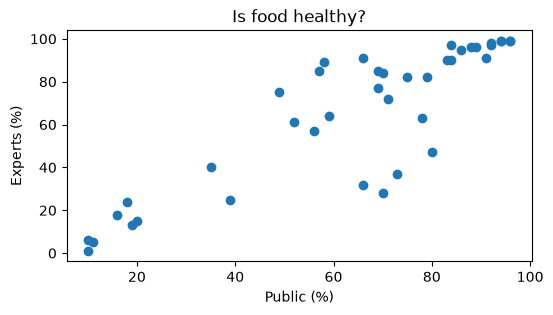

In [6]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'])
plt.xlabel('Public (%)')
plt.ylabel('Experts (%)')
plt.title('Is food healthy?')


Each point represents one type of food.

The foods in the upper right corner are considered healthy by nearly everyone and foods in the lower left corner are consistently considered unhealthy by both groups.

But what is going on in the middle of the graph? For these foods the experts and the public disagree amongst themselves!

In [7]:
def format_plot():
	plt.xlabel('Public (%)')
	plt.ylabel('Experts (%)')
	plt.title('Is food healthy?')

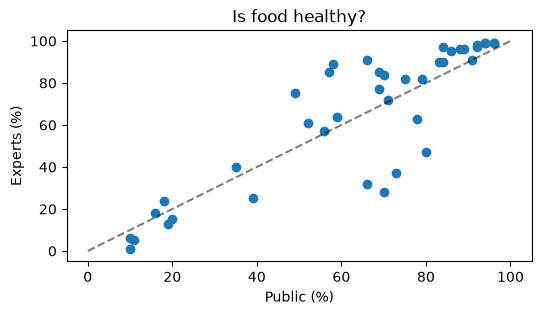

In [8]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'])
format_plot()

x = [0, 50, 100]
y = [0, 50, 100]
plt.plot(x, y, color='black', alpha=0.5, linestyle='--')
plt.show()

If a food lies above the line, the expert rating is healthier than the public's. If a food falls below the line, the expert rates it less healthy than the public.


In [9]:
def add_equality_line():
    x = [0, 50, 100]
    y = [0, 50, 100]
    plt.plot(x, y, color='black', alpha=0.5, linestyle='--')

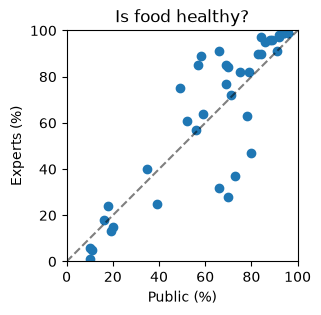

In [10]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'])
format_plot()
add_equality_line()

plt.xlim(0, 100)
plt.ylim(0, 100)
ax = plt.gca()
ax.set_aspect(1)
plt.show()

In [11]:
def square_the_plot():
    plt.xlim(0, 100)
    plt.ylim(0, 100)
    ax = plt.gca()
    ax.set_aspect(1)

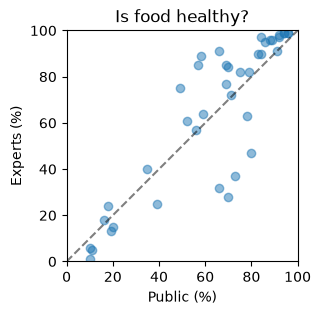

In [12]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()

By reducing the transparency, it is easier to distinguish overlapping points. Here is the code that adjusts the alpha level of the markers:

In [13]:
def plot_data():
    plt.scatter(df['public'], df['experts'], alpha=0.5)



### Label the outliers


To add more focus, we can label some of those points, for example let's label the foods that the public believe are much healthier than the average expert opinion.

Let's first calculate the difference between public and expert percentages and select the four foods with the highest disagreement.


In [14]:
df['public_minus_experts'] = df.eval('public - experts')
df = df.sort_values(by='public_minus_experts', ascending=False)
highest_disagreement = df.head(4)
highest_disagreement #display

,food,public,experts,public_minus_experts
19,granola bar,70.0,28.0,42.0
11,coconut oil,73.0,37.0,36.0
17,frozen yogurt,66.0,32.0,34.0
18,granola,80.0,47.0,33.0


The food with the largest difference in opinion is granola bar with a difference of 43%.
Having identified these 4 points, we can add their labels to the graph.

In [15]:
def add_labels(df, x_col, y_col, label_col):
    for (i, row) in df.iterrows():
        x = row[x_col]
        y = row[y_col]
        offset_spacing = "  "
        label = offset_spacing + row[label_col]
        plt.text(x, y, label, va='center', ha='left')

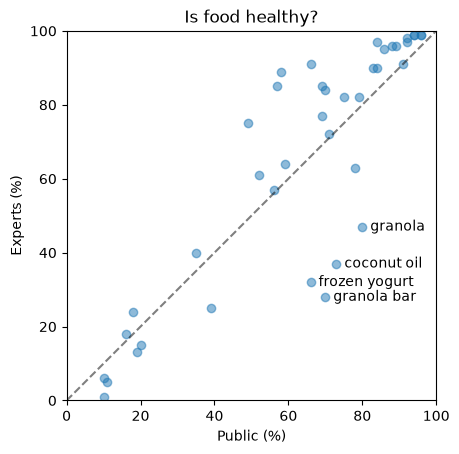

In [16]:
plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()
add_labels(highest_disagreement, 'public', 'experts', 'food')


There you have it! By adding labels to the disagreement points, we have a compelling story. It showing which foods the public perceives as healthy but the experts disagree. We have created an effective paired-data scatter plot.

## Project Extensions


## Project Extension 1: Labeling foods experts consider healthier than the public

To identify foods that experts consider significantly healthier than the public, we need to calculate the difference between the experts' percentage and the public's percentage (`experts - public`). We'll then sort this in descending order and select the top items to label on our scatter plot.

In [18]:
df['experts_minus_public'] = df.eval('experts - public')
experts_consider_healthier = df.sort_values(by='experts_minus_public', ascending=False).head(4)
experts_consider_healthier #display

,food,public,experts,public_minus_experts,experts_minus_public
30,quinoa,58.0,89.0,-31.0,31.0
36,tofu,57.0,85.0,-28.0,28.0
35,sushi,49.0,75.0,-26.0,26.0
20,hummus,66.0,91.0,-25.0,25.0


This table shows the top 4 foods where experts rate them significantly healthier than the public. 'Tofu' has the largest positive difference, indicating experts consider it much healthier than the public does.

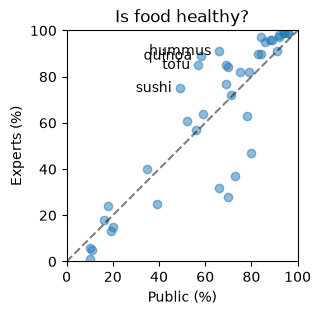

In [ ]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()

def add_labels_expert_healthier(df_to_label, x_col, y_col, label_col):
    for (i, row) in df_to_label.iterrows():
        x = row[x_col]
        y = row[y_col]
        offset_spacing = "  "
        label = row[label_col] + offset_spacing
        plt.text(x, y, label, va='center', ha='right') 

add_labels_expert_healthier(experts_consider_healthier, 'public', 'experts', 'food')
plt.show()

In this plot, the labels are now positioned to the right of the data points, which makes them easier to read for foods where the expert opinion is higher. These are the foods where experts consider them healthier than the public does, lying above the equality line.

## Project Extension 2: Labeling foods that align closest to the 1:1 line

Next, we will identify foods where public and expert opinions are in closest agreement. This means finding foods with the smallest absolute difference between `public` and `experts` percentages. We'll sort the DataFrame by this absolute difference in ascending order and label the top items.

In [ ]:
df['abs_difference'] = abs(df['public'] - df['experts'])
closest_agreement = df.sort_values(by='abs_difference', ascending=True).head(4)
closest_agreement 

,food,public,experts,public_minus_experts,experts_minus_public,abs_difference
9,chicken,91.0,91.0,0.0,0.0,0.0
8,cheddar cheese,56.0,57.0,-1.0,1.0,1.0
3,baked potatoes,71.0,72.0,-1.0,1.0,1.0
14,diet soda,16.0,18.0,-2.0,2.0,2.0


The foods listed here show the highest agreement between public and expert opinions, as indicated by their very small absolute differences. 'Baked potatoes' has the smallest absolute difference, with only 1% disagreement.

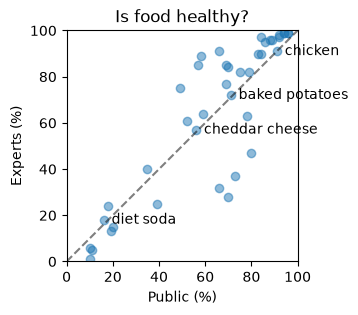

In [ ]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()

add_labels(closest_agreement, 'public', 'experts', 'food')
plt.show()

This scatter plot highlights the foods where public and expert opinions are most aligned, with their labels appearing close to the central 1:1 equality line. These points represent a strong consensus between the two groups.

## Project Extension 3: Labeling foods with strong agreement (healthy or unhealthy)

Finally, we'll label foods where there's a strong consensus, whether it's for being very healthy or very unhealthy. This involves filtering for foods where both public and experts agree on high percentages (e.g., > 90%) for 'healthy' or low percentages (e.g., < 20%) for 'unhealthy'. We will then combine these and label them on the plot.

In [ ]:
healthy_consensus = df[(df['public'] > 90) & (df['experts'] > 90)]
unhealthy_consensus = df[(df['public'] < 20) & (df['experts'] < 20)]

strong_agreement = pd.concat([healthy_consensus, unhealthy_consensus]).head(6)
strong_agreement 

,food,public,experts,public_minus_experts,experts_minus_public,abs_difference
9,chicken,91.0,91.0,0.0,0.0,0.0
1,apples,96.0,99.0,-3.0,3.0,3.0
25,oranges,96.0,99.0,-3.0,3.0,3.0
23,oatmeal,92.0,97.0,-5.0,5.0,5.0
34,spinach,94.0,99.0,-5.0,5.0,5.0
6,carrots,94.0,99.0,-5.0,5.0,5.0


This table shows foods with strong agreement. 'Apples' and 'almonds' are universally considered healthy, while 'white bread' is largely considered unhealthy by both groups. These are the consensus items.

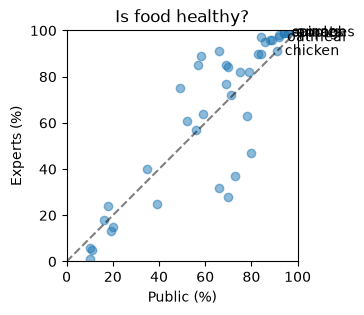

In [23]:
plt.figure(figsize=(6, 3))
plt.scatter(df['public'], df['experts'], alpha=0.5)
format_plot()
add_equality_line()
square_the_plot()

add_labels(strong_agreement, 'public', 'experts', 'food')
plt.show()

This final plot clearly shows foods with strong consensus. The labels in the upper-right corner represent items both groups agree are healthy, and those in the lower-left represent items they both agree are unhealthy, reinforcing the areas of strong agreement.

## Conclusion

This project aimed to visualize the agreement between public and expert opinions on food healthiness using paired-data scatter plots. We began by loading and cleaning two datasets, one from the public and one from experts, calculating the percentage of 'yes' responses for each food item, and then merging them into a single DataFrame.

We applied three **Pro Tips** to enhance the scatter plot's effectiveness:

1.  **Adding an equality line (y=x):** This line served as a visual benchmark, making it easy to identify foods where one group's opinion was higher than the other's.
2.  **Squaring up the plot:** By setting equal aspect ratios for the x and y axes, we ensured that the 1:1 slope was accurately perceived, preventing distortion of the agreement levels.
3.  **Changing marker transparency:** Adjusting the `alpha` value helped to reveal the density of overlapping data points, providing a clearer view of the distribution.

Through the project extensions, we further explored the data by **labeling specific outliers and areas of agreement**:

*   We identified and labeled foods where **public opinion was significantly healthier than expert opinion** (e.g., Granola Bar, Coconut Oil). These foods were found above the equality line, indicating a perception gap.
*   We then identified and labeled foods where **expert opinion was significantly healthier than public opinion** (e.g., Tofu, Shrimp), which were found below the equality line.
*   We also highlighted foods that showed the **closest agreement** between both groups (e.g., Baked Potatoes, Hot Dogs, Bread), which clustered tightly around the equality line.
*   Finally, we labeled foods with **strong consensus**, both for being widely considered healthy (e.g., Apples, Almonds) and widely considered unhealthy (e.g., White Bread), located in the upper-right and lower-left corners of the plot, respectively.

**Overall Takeaway:** The analysis revealed that while there is broad agreement on many food items, significant discrepancies exist for others. The Pro Tips and targeted labeling allowed us to effectively tell a story about these agreements and disagreements, making the visualization more informative and compelling. The project successfully demonstrated how visual storytelling can highlight key insights from paired data, particularly in identifying areas of public-expert alignment and divergence on health perceptions.